# Respiratory Anomaly Detection Project
本專案模擬臨床呼吸資料（SpO2 與 RR），透過 Isolation Forest 模型進行異常偵測與視覺化分析。

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest

# 載入資料
df = pd.read_csv("simulated_resp_data.csv", parse_dates=["time"])
df.head()
# df.info()


,time,SpO2,RR,label
0,2025-01-01 00:00:00,97.496714,17.171005,0
1,2025-01-01 00:00:01,96.861736,17.439819,0
2,2025-01-01 00:00:02,97.647689,18.747294,0
3,2025-01-01 00:00:03,98.523030,18.610370,0
4,2025-01-01 00:00:04,96.765847,17.979098,0


## SpO2 時間序列圖

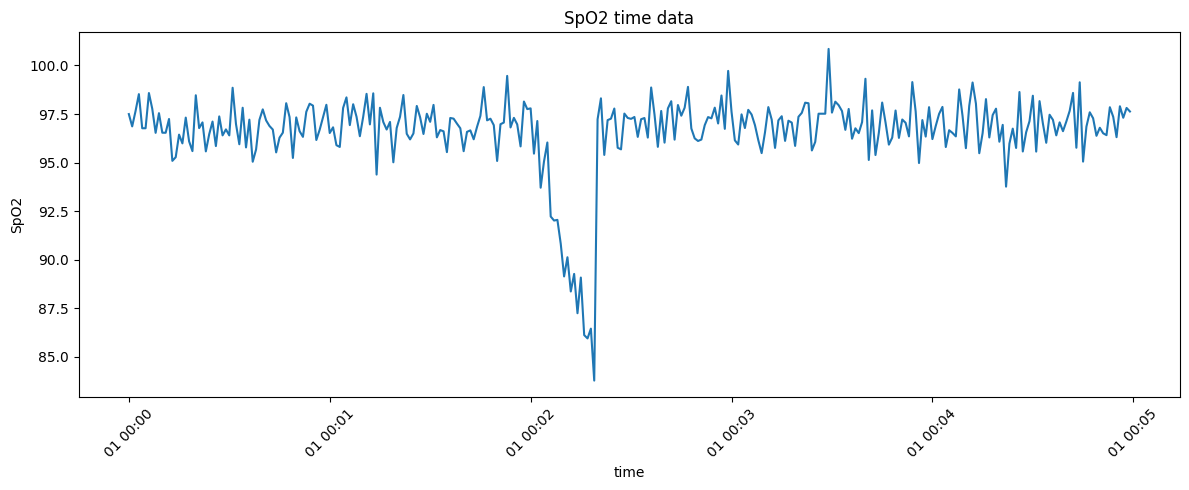

In [12]:
plt.figure(figsize=(12, 5))
sns.lineplot(x='time', y='SpO2', data=df)
plt.title('SpO2 time data')
plt.xlabel('time')
plt.ylabel('SpO2')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## IsolationForest 進行異常偵測

In [20]:
features = df[['SpO2', 'RR']]
model = IsolationForest(contamination=0.07, random_state=42)
# model = IsolationForest(contamination=0.15, random_state=42)
df['anomaly_pred'] = model.fit_predict(features)
df['anomaly_pred'] = df['anomaly_pred'].map({1: 0, -1: 1})  # 轉換為 0/1
df[['SpO2', 'RR', 'label', 'anomaly_pred']].head()
# print(df["anomaly_pred"].sum())


,SpO2,RR,label,anomaly_pred
0,97.496714,17.171005,0,0
1,96.861736,17.439819,0,0
2,97.647689,18.747294,0,0
3,98.523030,18.610370,0,0
4,96.765847,17.979098,0,0


## 異常點視覺化

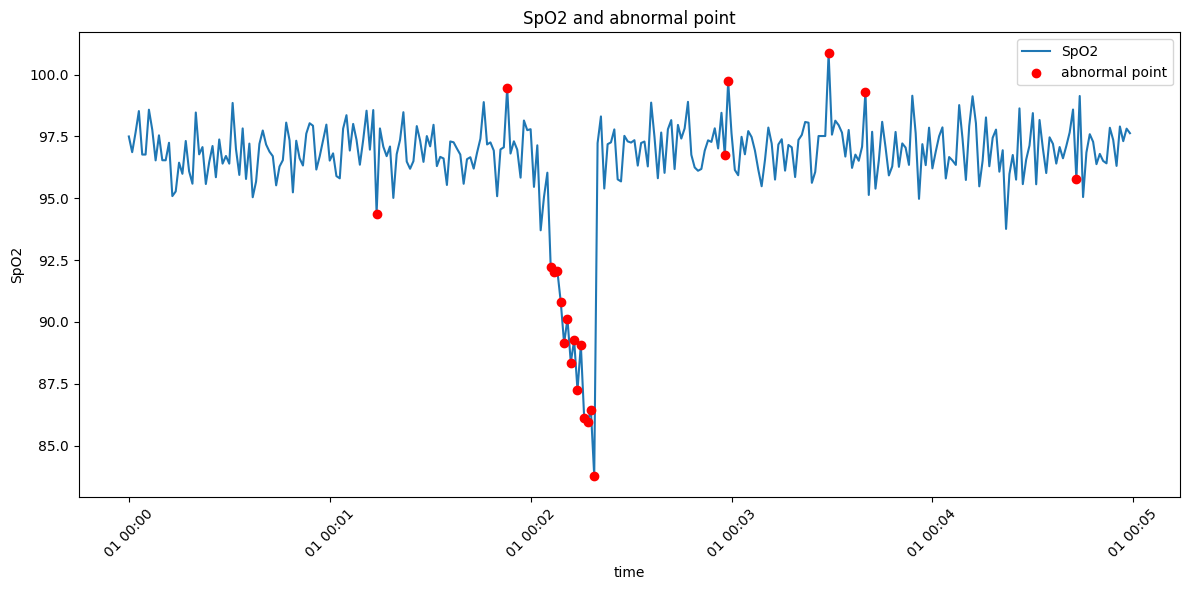

In [15]:
plt.figure(figsize=(12, 6))
sns.lineplot(x='time', y='SpO2', data=df, label='SpO2')
plt.scatter(df[df['anomaly_pred'] == 1]['time'],
            df[df['anomaly_pred'] == 1]['SpO2'],
            color='red', label='abnormal point', zorder=5)
plt.title('SpO2 and abnormal point')
plt.xlabel('time')
plt.ylabel('SpO2')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


## 簡單結論
本專案成功模擬 SpO2 急降的臨床情境，並透過 Isolation Forest 模型進行異常點預測，顯示模型能夠有效標示潛在異常事件。
